In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

In [2]:
df = pd.read_csv('train_data/turb_train_data.csv')
df_all = pd.read_csv('train_data/turb_train_data.csv')

In [6]:
df_all.head()

,TURB,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,B4_B3,B5_B4,B7_B4
0,19.3,0.0032,0.0046,0.0314,0.0421,0.0446,0.0399,0.0176,0.0154,0.0110,0.0076,1.059382,0.894619,0.345291
1,15.1,0.0518,0.0457,0.0805,0.0941,0.0947,0.0997,0.0690,0.0672,0.0628,0.0595,1.006376,1.052798,0.709609
2,14.0,0.0117,0.0118,0.0366,0.0486,0.0486,0.0501,0.0202,0.0208,0.0156,0.0128,1.000000,1.030864,0.427984
3,14.9,0.0117,0.0118,0.0366,0.0486,0.0486,0.0501,0.0202,0.0208,0.0156,0.0128,1.000000,1.030864,0.427984
4,13.4,0.0560,0.0482,0.0827,0.0948,0.0979,0.0950,0.0731,0.0686,0.0749,0.0625,1.032700,0.970378,0.700715


MSE: 37.32862592289763
R²: 0.6469937997937378
Cross-validated R²: 0.4557822273977944 (± 0.254)
Feature Importances:
 B4_B3    0.408164
B7       0.106899
B5       0.073344
B5_B4    0.072892
B4       0.068579
B12      0.055399
B3       0.046708
B8       0.046220
B11      0.042388
B2       0.034820
B6       0.023057
B8A      0.021530
dtype: float64


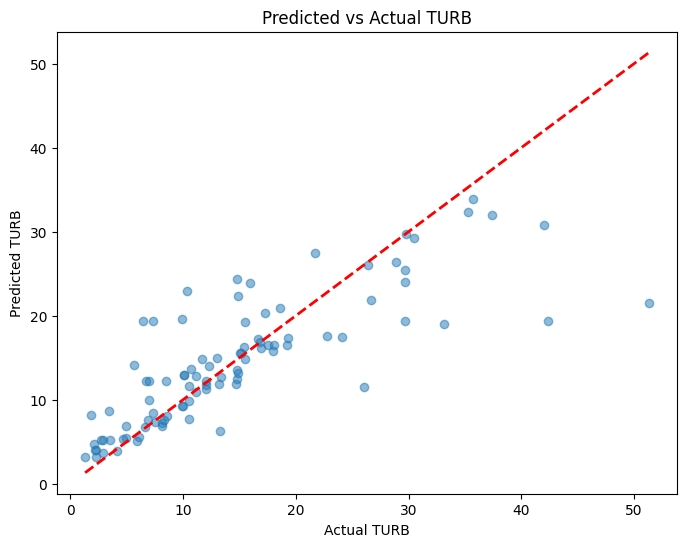

TURB Range: Min = 0.9, Max = 144.0


In [3]:
df_all["B4_B3"] = df_all["B4"] / df_all["B3"].replace(0, np.finfo(float).eps)  # Avoid division by zero
df_all["B5_B4"] = df_all["B5"] / df_all["B4"].replace(0, np.finfo(float).eps)

# Features and target
X = df_all.drop("TURB", axis=1)  # Drop TURB (and "date" if added)
y = df_all["TURB"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest with tuned parameters
model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
# For XGBoost, uncomment the next line and comment the one above
# model = XGBRegressor(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate on test set
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse}")
print(f"R²: {r2}")

# Cross-validation for robustness
cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print(f"Cross-validated R²: {cv_scores.mean()} (± {cv_scores.std():.3f})")

# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
print("Feature Importances:\n", importances.sort_values(ascending=False))

# Residual plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual TURB")
plt.ylabel("Predicted TURB")
plt.title("Predicted vs Actual TURB")
plt.show()

# Print TURB range for context
print(f"TURB Range: Min = {y.min()}, Max = {y.max()}")

--- Linear Regression ---
MSE: 47.710533406165965
R²: 0.5488150530289541
Cross-validated R²: 0.2575415878679522 (± 0.288)
--- Decision Tree ---
MSE: 52.576132978723386
R²: 0.5028024615025103
Cross-validated R²: -0.13034821758788612 (± 0.828)
--- Random Forest ---
MSE: 36.316796869516075
R²: 0.6565623794175977
Cross-validated R²: 0.43380884292330124 (± 0.242)
--- Gradient Boosting ---
MSE: 26.79810566970266
R²: 0.7465779352626838
Cross-validated R²: 0.42936865898471666 (± 0.212)
--- XGBoost ---
MSE: 30.03411442318322
R²: 0.7159759207052805
Cross-validated R²: 0.4235906454856063 (± 0.183)
--- SVR ---
MSE: 90.79997412366532
R²: 0.1413304655138532
Cross-validated R²: 0.09441459869453643 (± 0.096)


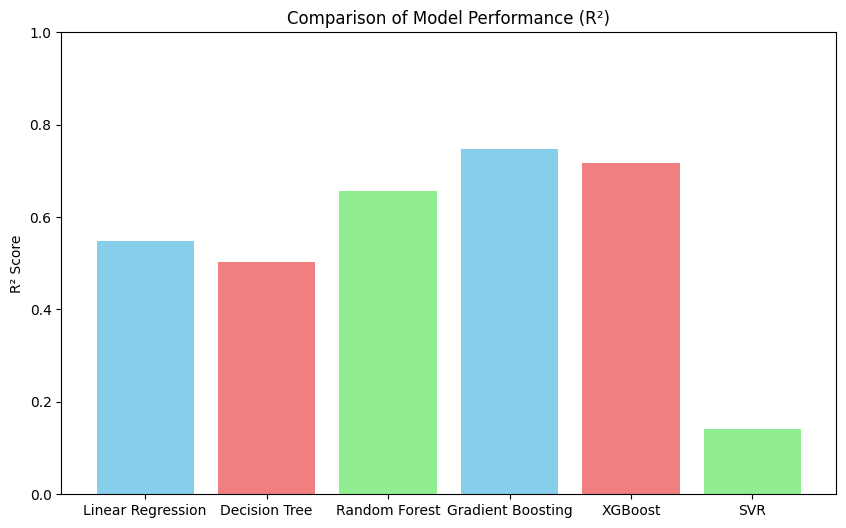

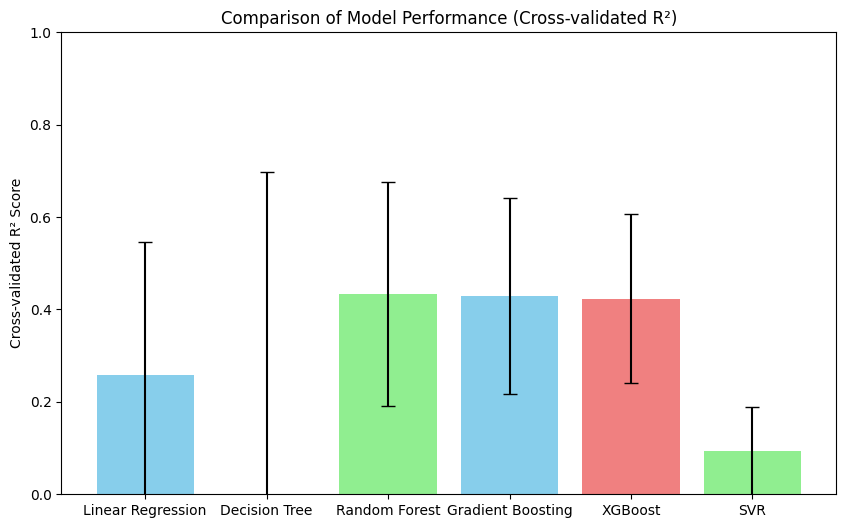

In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=5, random_state=42),
    'SVR': SVR(kernel='rbf'), # Using default RBF kernel
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
    results[name] = {'MSE': mse, 'R²': r2, 'CV_R²_mean': cv_scores.mean(), 'CV_R²_std': cv_scores.std()}
    print(f"--- {name} ---")
    print(f"MSE: {mse}")
    print(f"R²: {r2}")
    print(f"Cross-validated R²: {cv_scores.mean()} (± {cv_scores.std():.3f})")

# Plotting the R-squared scores
model_names = list(results.keys())
r2_scores = [results[name]['R²'] for name in model_names]

plt.figure(figsize=(10, 6))
plt.bar(model_names, r2_scores, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.ylabel("R² Score")
plt.title("Comparison of Model Performance (R²)")
plt.ylim([0, 1])
plt.show()

# Plotting the Cross-validated R-squared scores
cv_r2_means = [results[name]['CV_R²_mean'] for name in model_names]
cv_r2_stds = [results[name]['CV_R²_std'] for name in model_names]

plt.figure(figsize=(10, 6))
plt.bar(model_names, cv_r2_means, color=['skyblue', 'lightcoral', 'lightgreen'], yerr=cv_r2_stds, capsize=5)
plt.ylabel("Cross-validated R² Score")
plt.title("Comparison of Model Performance (Cross-validated R²)")
plt.ylim([0, 1])
plt.show()

In [17]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

c:\Users\sujal\OneDrive\Desktop\Projects\waterquality_model\venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
--- Neural Network ---
MSE: 28.215441885853316
R²: 0.7331745897146452


c:\Users\sujal\OneDrive\Desktop\Projects\waterquality_model\venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


c:\Users\sujal\OneDrive\Desktop\Projects\waterquality_model\venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


c:\Users\sujal\OneDrive\Desktop\Projects\waterquality_model\venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


c:\Users\sujal\OneDrive\Desktop\Projects\waterquality_model\venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Cross-validated R² (Neural Network): 0.6066909023369332 (± 0.235)


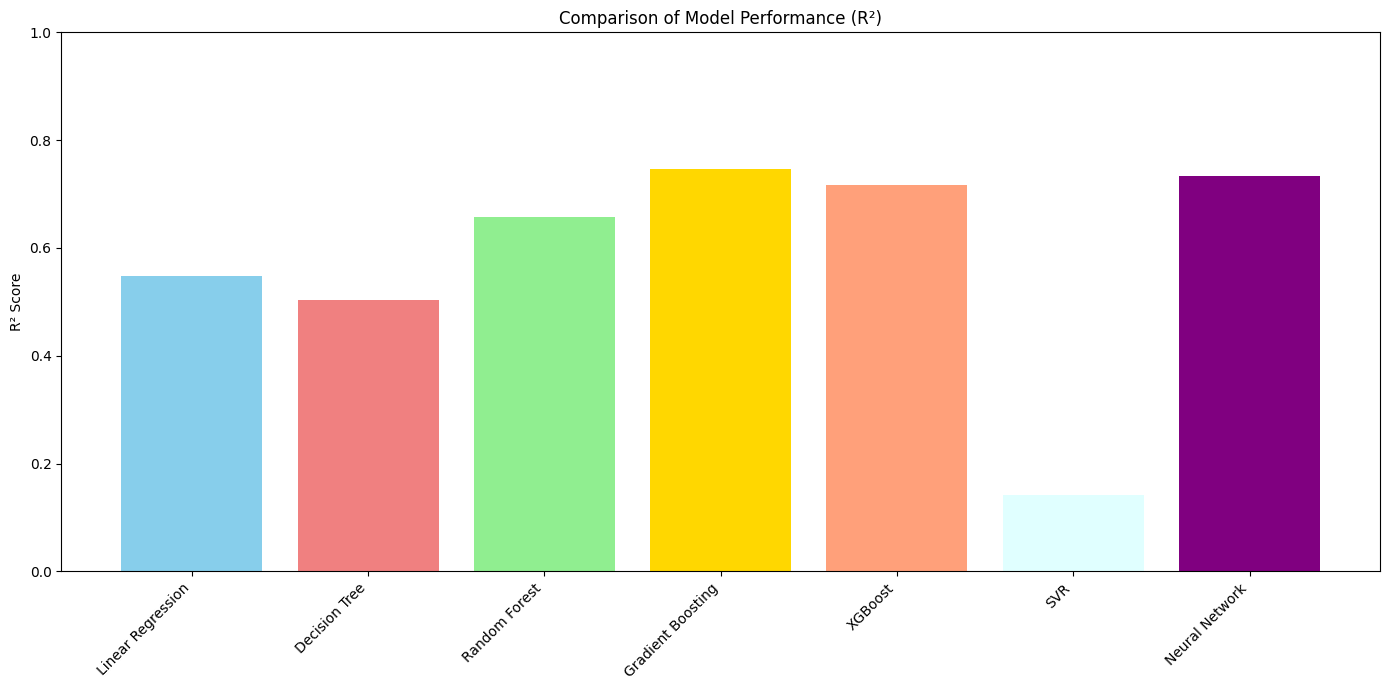

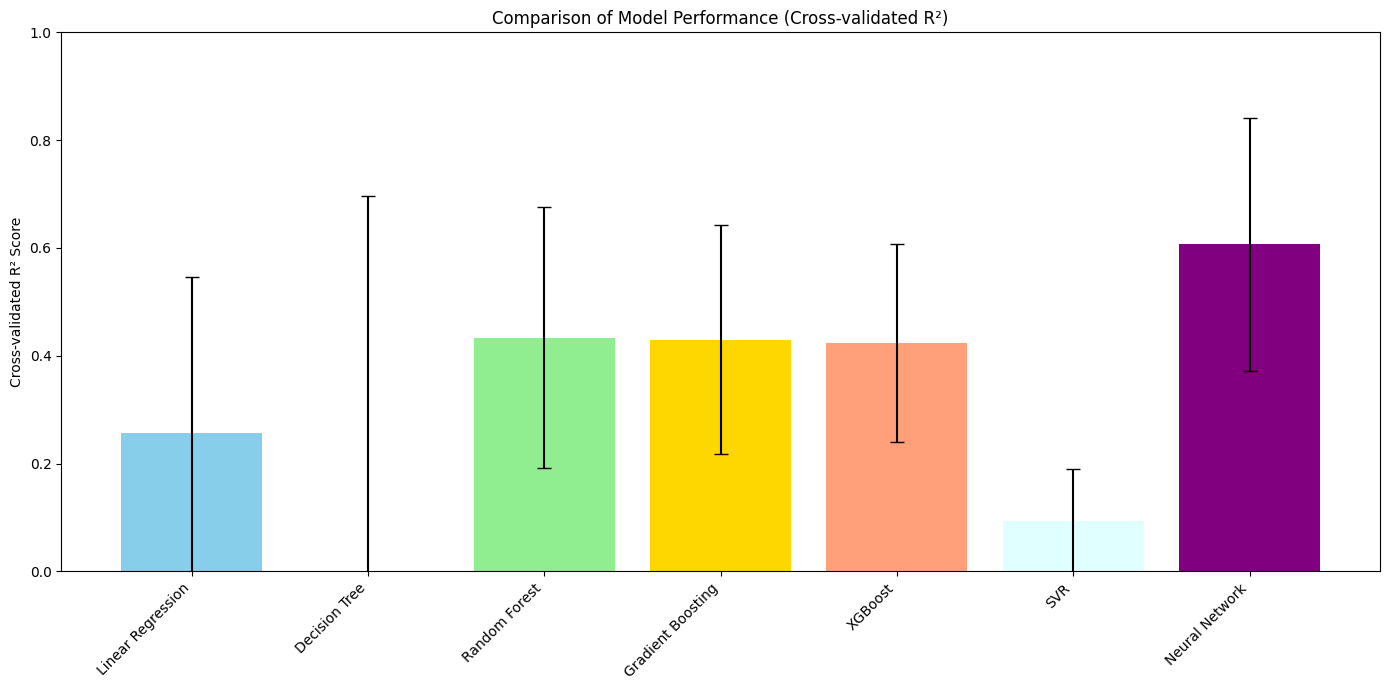

In [18]:
# Features and target
X = df_all.drop("TURB", axis=1)
y = df_all["TURB"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled_full = scaler.fit_transform(X) # Scale full data for CV

# Define the Neural Network model
def create_model():
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    optimizer = Adam(learning_rate=0.01)
    model.compile(optimizer=optimizer, loss='mse')
    return model

# Train the Neural Network model
nn_model = create_model()
history = nn_model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, verbose=0)

# Predict and evaluate on test set
y_pred_nn = nn_model.predict(X_test_scaled)
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)
print(f"--- Neural Network ---")
print(f"MSE: {mse_nn}")
print(f"R²: {r2_nn}")
results['Neural Network'] = {'MSE': mse_nn, 'R²': r2_nn, 'CV_R²_mean': None, 'CV_R²_std': None}

# Cross-validation for Neural Network (Manual Implementation)
def create_cv_model(input_shape):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=input_shape))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    optimizer = Adam(learning_rate=0.01)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mse']) # Keep mse for consistency
    return model

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores_nn = []
cv_mse_scores_nn = []
X_scaled_full = scaler.fit_transform(X)

for train_index, val_index in kf.split(X_scaled_full):
    X_train_cv, X_val_cv = X_scaled_full[train_index], X_scaled_full[val_index]
    y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

    model_cv = create_cv_model(input_shape=(X_train_cv.shape[1],))
    model_cv.fit(X_train_cv, y_train_cv, epochs=80, batch_size=16, verbose=0)

    y_pred_cv = model_cv.predict(X_val_cv)
    mse_cv = mean_squared_error(y_val_cv, y_pred_cv)
    r2_cv = r2_score(y_val_cv, y_pred_cv)

    cv_mse_scores_nn.append(mse_cv)
    cv_r2_scores_nn.append(r2_cv)

print(f"Cross-validated R² (Neural Network): {np.mean(cv_r2_scores_nn)} (± {np.std(cv_r2_scores_nn):.3f})")
results['Neural Network']['CV_R²_mean'] = np.mean(cv_r2_scores_nn)
results['Neural Network']['CV_R²_std'] = np.std(cv_r2_scores_nn)

# Plotting the R-squared scores
model_names = list(results.keys())
r2_scores = [results[name]['R²'] for name in model_names]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'lightsalmon', 'lightcyan', 'purple'] # Added color for NN

plt.figure(figsize=(14, 7))
plt.bar(model_names, r2_scores, color=colors)
plt.ylabel("R² Score")
plt.title("Comparison of Model Performance (R²)")
plt.ylim([0, 1])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plotting the Cross-validated R-squared scores
cv_r2_means = [results[name]['CV_R²_mean'] for name in model_names]
cv_r2_stds = [results[name]['CV_R²_std'] for name in model_names]

plt.figure(figsize=(14, 7))
plt.bar(model_names, cv_r2_means, color=colors, yerr=cv_r2_stds, capsize=5)
plt.ylabel("Cross-validated R² Score")
plt.title("Comparison of Model Performance (Cross-validated R²)")
plt.ylim([0, 1])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, LeakyReLU, Conv1D, Flatten, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [27]:
X = df_all.drop("TURB", axis=1)
y = df_all["TURB"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled_full = scaler.fit_transform(X)

# Define different NN architectures
def create_baseline_model(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape)) # Use Input layer
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
    return model

def create_deeper_model(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape)) # Use Input layer
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
    return model

def create_bn_model(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape)) # Use Input layer
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(32, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
    return model

def create_dropout_model(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape)) # Use Input layer
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
    return model

def create_leaky_relu_model(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape)) # Use Input layer
    model.add(Dense(64, kernel_initializer='he_normal'))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dense(32, kernel_initializer='he_normal'))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
    return model

def create_cnn_model(input_shape):
    # Reshape input for CNN (assuming bands are the 'sequence')
    input_shape_cnn = (input_shape[0], 1)
    model = Sequential()
    model.add(Input(shape=input_shape_cnn)) # Use Input layer
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
    return model

nn_architectures = {
    'Baseline': create_baseline_model,
    'Deeper': create_deeper_model,
    'Batch Normalization': create_bn_model,
    'Dropout': create_dropout_model,
    'Leaky ReLU': create_leaky_relu_model,
    'CNN': create_cnn_model,
}

results_nn = {}

for name, create_model_func in nn_architectures.items():
    print(f"--- Training and evaluating {name} ---")

    # Handle CNN input shape
    input_shape = (X_train_scaled.shape[1],)
    if name == 'CNN':
        X_train_scaled_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
        X_test_scaled_cnn = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))
        input_shape = (X_train_scaled_cnn.shape[1], 1)
        X_scaled_full_cnn = X_scaled_full.reshape((X_scaled_full.shape[0], X_scaled_full.shape[1], 1))

    model = create_model_func(input_shape)
    model.fit(X_train_scaled if name != 'CNN' else X_train_scaled_cnn, y_train, epochs=100, batch_size=16, verbose=0)

    # Evaluate on test set
    X_test_to_use = X_test_scaled if name != 'CNN' else X_test_scaled_cnn
    y_pred = model.predict(X_test_to_use)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"Test Set - MSE: {mse:.4f}, R²: {r2:.4f}, MAE: {mae:.4f}")

    # Cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2_scores = []
    cv_mae_scores = []
    X_full_to_use = X_scaled_full if name != 'CNN' else X_scaled_full_cnn

    for train_index, val_index in kf.split(X_full_to_use):
        X_train_cv, X_val_cv = X_full_to_use[train_index], X_full_to_use[val_index]
        y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

        model_cv = create_model_func(input_shape)
        model_cv.fit(X_train_cv, y_train_cv, epochs=80, batch_size=16, verbose=0)
        y_pred_cv = model_cv.predict(X_val_cv)
        r2_cv = r2_score(y_val_cv, y_pred_cv)
        mae_cv = mean_absolute_error(y_val_cv, y_pred_cv)
        cv_r2_scores.append(r2_cv)
        cv_mae_scores.append(mae_cv)

    mean_cv_r2 = np.mean(cv_r2_scores)
    std_cv_r2 = np.std(cv_r2_scores)
    mean_cv_mae = np.mean(cv_mae_scores)
    std_cv_mae = np.std(cv_mae_scores)
    print(f"Cross-validated R²: {mean_cv_r2:.4f} (± {std_cv_r2:.3f}), MAE: {mean_cv_mae:.4f} (± {std_cv_mae:.4f})\n")

    results_nn[name] = {'Test R²': r2, 'Test MAE': mae, 'CV R² Mean': mean_cv_r2, 'CV R² Std': std_cv_r2, 'CV MAE Mean': mean_cv_mae, 'CV MAE Std': std_cv_mae}

# Compare the results
print("\n--- Comparison of Neural Network Architectures ---")
df_results_nn = pd.DataFrame.from_dict(results_nn, orient='index')
print(df_results_nn)

--- Training and evaluating Baseline ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Test Set - MSE: 35.1566, R²: 0.6675, MAE: 3.9718
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Cross-validated R²: 0.6279 (± 0.208), MAE: 3.8760 (± 0.4265)

--- Training and evaluating Deeper ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Test Set - MSE: 37.0945, R²: 0.6492, MAE: 3.8421
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Cross-validated R²: 0.5961 (± 0.248), MAE: 3.8720 (± 0.6043)

--- Training and evaluating Batch Normalization ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Test Set - MSE: 44.5491, R²: 0.5787, MAE: 4.4061
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s

c:\Users\sujal\OneDrive\Desktop\Projects\waterquality_model\venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Test Set - MSE: 24.5843, R²: 0.7675, MAE: 3.2336


c:\Users\sujal\OneDrive\Desktop\Projects\waterquality_model\venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


...

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


c:\Users\sujal\OneDrive\Desktop\Projects\waterquality_model\venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


c:\Users\sujal\OneDrive\Desktop\Projects\waterquality_model\venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Cross-validated R²: 0.6090 (± 0.236), MAE: 3.8992 (± 0.7817)

--- Training and evaluating CNN ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Test Set - MSE: 31.3571, R²: 0.7035, MAE: 3.3381
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Cross-validated R²: 0.5894 (± 0.275), MAE: 3.8089 (± 0.7966)


--- Comparison of Neural Network Architectures ---
                      Test R²  Test MAE  CV R² Mean  CV R² Std  CV MAE Mean  \
Baseline             0.667534  3.971807    0.627923   0.207544     3.876001   
Deeper               0.649208  3.842066    0.596066   0.247993     3.872015   
Batch Normalization  0.578712  4.406072   -3.890948   8.620342     5.553473   
Dropout              0.701216  3.573498    0.640198   0.247921     3.702558   
Leaky ReLU           0.767514  3.233641    0.608958   0.236405     3.899235   


--- Comparison of Neural Network Architectures ---
                      Test R²  Test MAE  CV R² Mean  CV R² Std  CV MAE Mean  \
Baseline             0.667534  3.971807    0.627923   0.207544     3.876001   
Deeper               0.649208  3.842066    0.596066   0.247993     3.872015   
Batch Normalization  0.578712  4.406072   -3.890948   8.620342     5.553473   
Dropout              0.701216  3.573498    0.640198   0.247921     3.702558   
Leaky ReLU           0.767514  3.233641    0.608958   0.236405     3.899235   
CNN                  0.703464  3.338099    0.589353   0.275001     3.808930   

                     CV MAE Std  
Baseline               0.426546  
Deeper                 0.604276  
Batch Normalization    1.962032  
Dropout                0.541537  
Leaky ReLU             0.781718  
CNN                    0.796557  


C:\Users\sujal\AppData\Local\Temp\ipykernel_10660\1968439090.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(model_names))


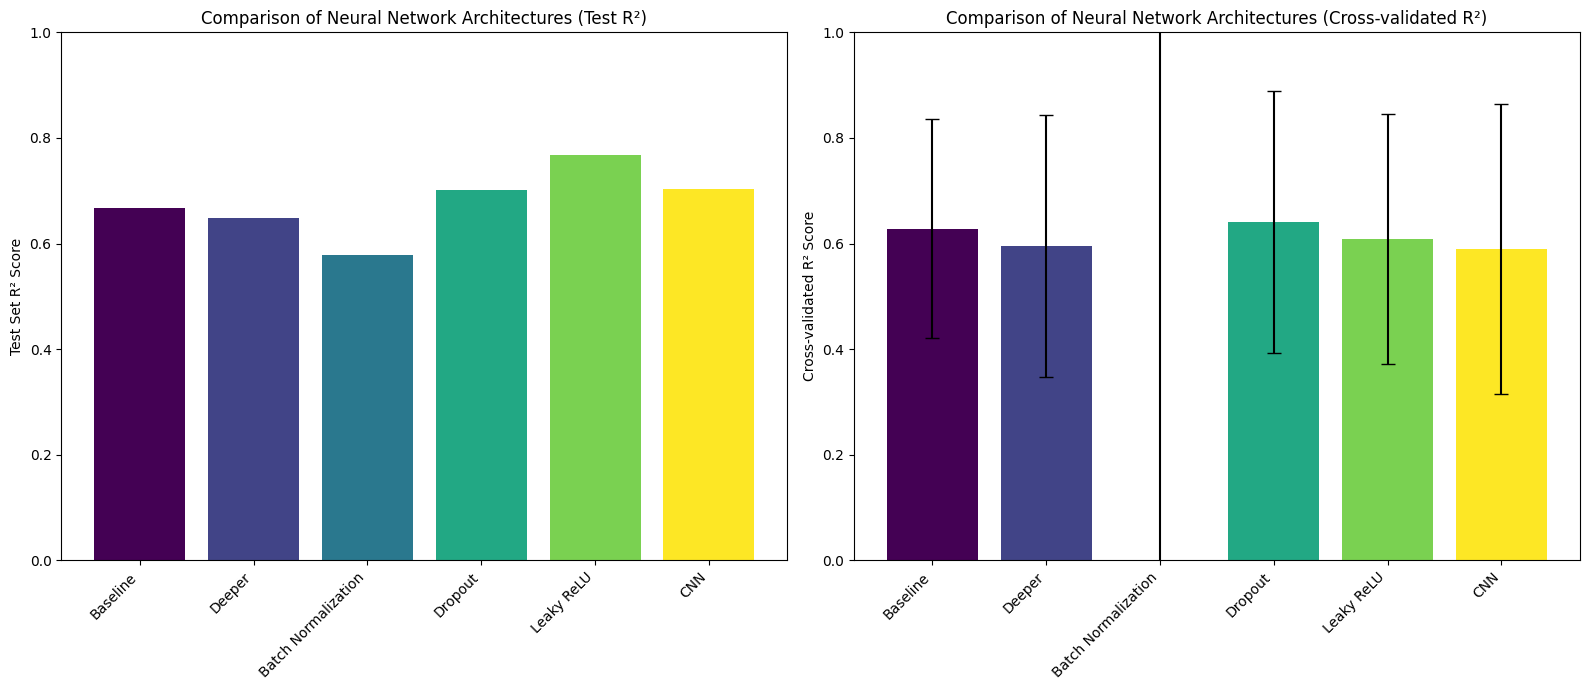

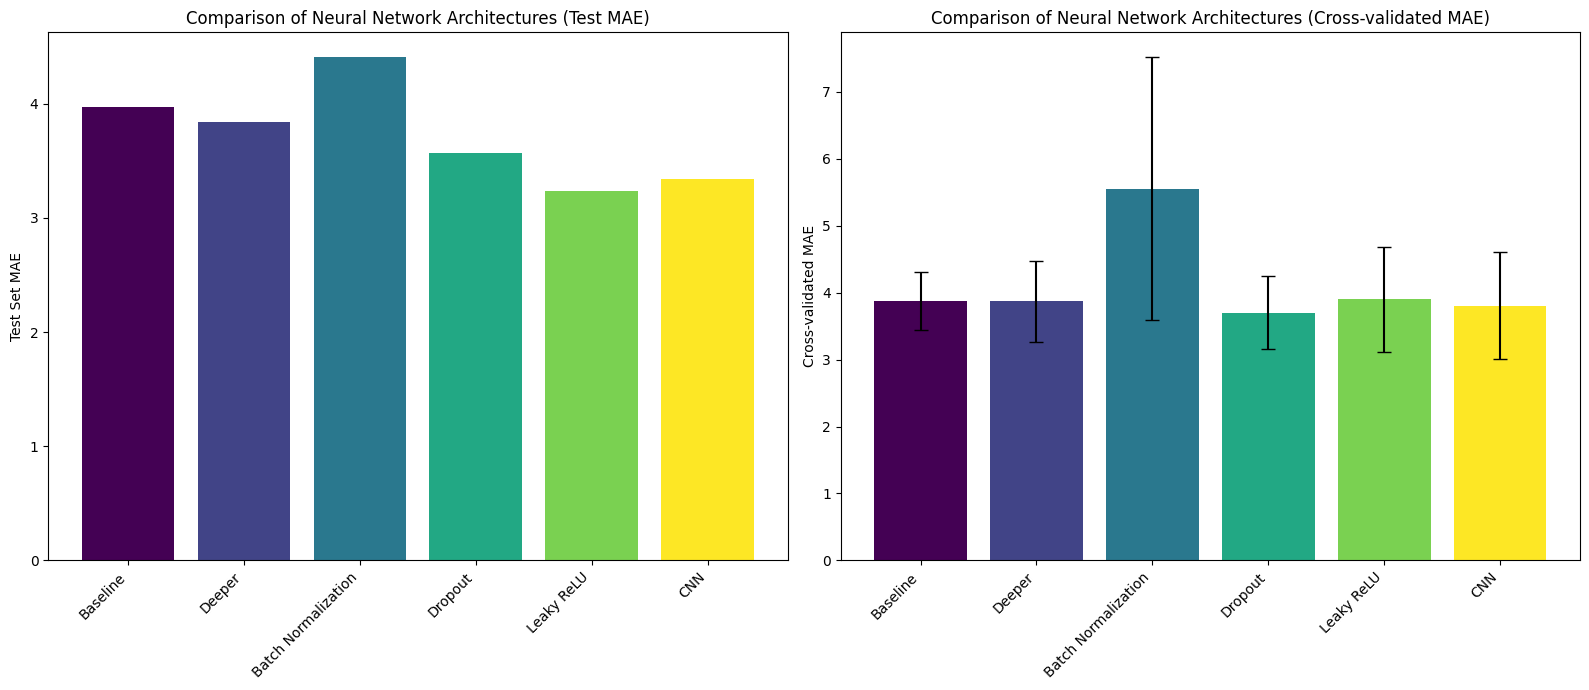

In [28]:
# Compare the results
print("\n--- Comparison of Neural Network Architectures ---")
df_results_nn = pd.DataFrame.from_dict(results_nn, orient='index')
print(df_results_nn)

# Plotting the R-squared scores
model_names = df_results_nn.index
test_r2_scores = df_results_nn['Test R²']
cv_r2_means = df_results_nn['CV R² Mean']
cv_r2_stds = df_results_nn['CV R² Std']
cmap = plt.cm.get_cmap('viridis', len(model_names))
colors = [cmap(i) for i in range(len(model_names))]

fig, axes = plt.subplots(1, 2, figsize=(16, 7)) # Increased figure size

axes[0].bar(model_names, test_r2_scores, color=colors)
axes[0].set_ylabel("Test Set R² Score")
axes[0].set_title("Comparison of Neural Network Architectures (Test R²)")
axes[0].set_ylim([0, 1])
plt.sca(axes[0])
plt.xticks(rotation=45, ha='right')

axes[1].bar(model_names, cv_r2_means, color=colors, yerr=cv_r2_stds, capsize=5)
axes[1].set_ylabel("Cross-validated R² Score")
axes[1].set_title("Comparison of Neural Network Architectures (Cross-validated R²)")
axes[1].set_ylim([0, 1])
plt.sca(axes[1])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Plotting the MAE scores
test_mae_scores = df_results_nn['Test MAE']
cv_mae_means = df_results_nn['CV MAE Mean']
cv_mae_stds = df_results_nn['CV MAE Std']

fig_mae, axes_mae = plt.subplots(1, 2, figsize=(16, 7))

axes_mae[0].bar(model_names, test_mae_scores, color=colors)
axes_mae[0].set_ylabel("Test Set MAE")
axes_mae[0].set_title("Comparison of Neural Network Architectures (Test MAE)")
plt.sca(axes_mae[0])
plt.xticks(rotation=45, ha='right')

axes_mae[1].bar(model_names, cv_mae_means, color=colors, yerr=cv_mae_stds, capsize=5)
axes_mae[1].set_ylabel("Cross-validated MAE")
axes_mae[1].set_title("Comparison of Neural Network Architectures (Cross-validated MAE)")
plt.sca(axes_mae[1])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()